# Customer Churn Data

In [1]:
# importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split


# Helper functions

In [21]:
def load_data(file_path):
    data = pd.read_csv(file_path)
    return data
def save_data(data, output_file_path):
    os.makedirs(os.path.dirname(output_file_path), exist_ok=True)

    data.to_csv(output_file_path, index=False)

    parquet_path = output_file_path.replace(".csv", ".parquet") 
    data.to_parquet(parquet_path, index=False, engine="pyarrow")  # preserves datatypes (important for categorical features)


# Loading the data 

In [4]:
data = load_data("../dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Getting to know the data

In [5]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
preprocessed_data = data.copy()

### changing some of the features datatype

In [8]:
# convert total charges to numeric
preprocessed_data['TotalCharges'] = pd.to_numeric(preprocessed_data['TotalCharges'], errors='coerce')
preprocessed_data["SeniorCitizen"] = (preprocessed_data["SeniorCitizen"].map({0: "No", 1: "Yes"}))

In [9]:
preprocessed_data.describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


# handling numerical features

In [10]:
# fill missing values with the median for numeric columns
numeric_cols = preprocessed_data.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    preprocessed_data[col].fillna(preprocessed_data[col].median(), inplace=True)

# normalize/standardize numeric variables: For XGBoost, normalization is not strictly necessary, but it can help with convergence and performance. Here, we will standardize the numeric columns to have a mean of 0 and a standard deviation of 1.
preprocessed_data[numeric_cols] = (preprocessed_data[numeric_cols] - preprocessed_data[numeric_cols].mean()) / preprocessed_data[numeric_cols].std()


/var/folders/96/vqrfcvzj57l2h02bbvc1nkrc0000gn/T/ipykernel_65199/233635046.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  preprocessed_data[col].fillna(preprocessed_data[col].median(), inplace=True)
/var/folders/96/vqrfcvzj57l2h02bbvc1nkrc0000gn/T/ipykernel_65199/233635046.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which 

# Handling categorical variables

In [11]:

# identify the number of missing values in categorical columns
categorical_cols = preprocessed_data.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"Missing values in {col}: {preprocessed_data[col].isnull().sum()}")
    
# identify categorical columns with missing values and fill them with the mode
for col in categorical_cols:
    if preprocessed_data[col].isnull().any():
        preprocessed_data[col].fillna(preprocessed_data[col].mode()[0], inplace=True)


Missing values in customerID: 0
Missing values in gender: 0
Missing values in SeniorCitizen: 0
Missing values in Partner: 0
Missing values in Dependents: 0
Missing values in PhoneService: 0
Missing values in MultipleLines: 0
Missing values in InternetService: 0
Missing values in OnlineSecurity: 0
Missing values in OnlineBackup: 0
Missing values in DeviceProtection: 0
Missing values in TechSupport: 0
Missing values in StreamingTV: 0
Missing values in StreamingMovies: 0
Missing values in Contract: 0
Missing values in PaperlessBilling: 0
Missing values in PaymentMethod: 0
Missing values in Churn: 0


In [12]:
# capture unique values in categorical columns
for col in categorical_cols:
    print(f"Unique values in {col}: {preprocessed_data[col].nunique()}")

Unique values in customerID: 7043
Unique values in gender: 2
Unique values in SeniorCitizen: 2
Unique values in Partner: 2
Unique values in Dependents: 2
Unique values in PhoneService: 2
Unique values in MultipleLines: 3
Unique values in InternetService: 3
Unique values in OnlineSecurity: 3
Unique values in OnlineBackup: 3
Unique values in DeviceProtection: 3
Unique values in TechSupport: 3
Unique values in StreamingTV: 3
Unique values in StreamingMovies: 3
Unique values in Contract: 3
Unique values in PaperlessBilling: 2
Unique values in PaymentMethod: 4
Unique values in Churn: 2


In [13]:
# drop customerID as it is not a useful feature for prediction
preprocessed_data.drop('customerID', axis=1, inplace=True)
categorical_cols = categorical_cols.drop('customerID')

In [14]:
# convert categorical columns. For XGBoost, we can convert categorical variables to category dtype in pandas, which allows XGBoost to handle them directly without needing one-hot encoding. This is more efficient and can lead to better performance.
for col in categorical_cols:
    preprocessed_data[col] = preprocessed_data[col].astype("category")

In [15]:
preprocessed_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   gender            7043 non-null   category
 1   SeniorCitizen     7043 non-null   category
 2   Partner           7043 non-null   category
 3   Dependents        7043 non-null   category
 4   tenure            7043 non-null   float64 
 5   PhoneService      7043 non-null   category
 6   MultipleLines     7043 non-null   category
 7   InternetService   7043 non-null   category
 8   OnlineSecurity    7043 non-null   category
 9   OnlineBackup      7043 non-null   category
 10  DeviceProtection  7043 non-null   category
 11  TechSupport       7043 non-null   category
 12  StreamingTV       7043 non-null   category
 13  StreamingMovies   7043 non-null   category
 14  Contract          7043 non-null   category
 15  PaperlessBilling  7043 non-null   category
 16  PaymentMethod     7043 n

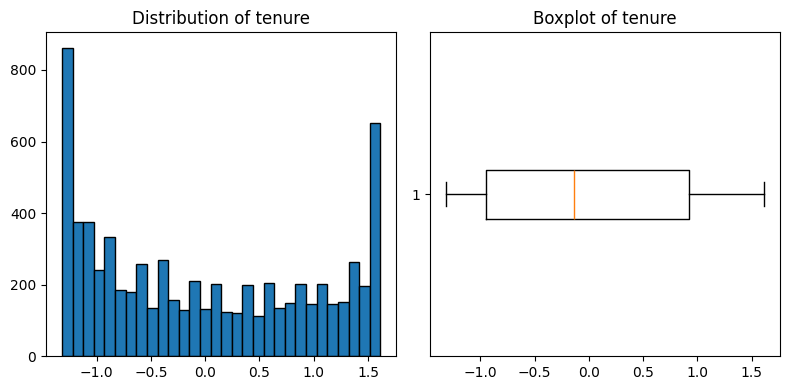

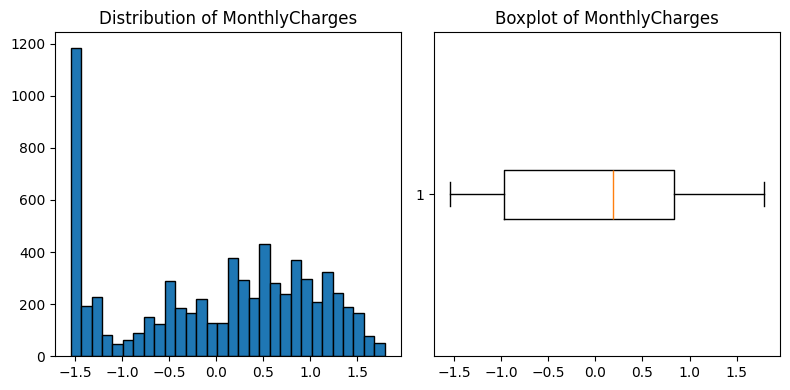

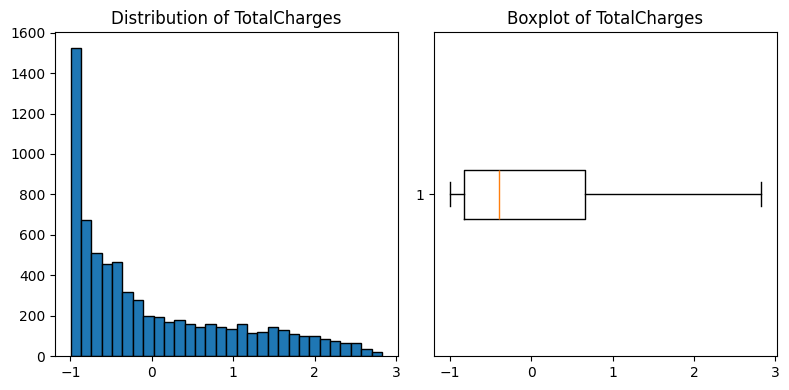

In [16]:
# check distribution of the numerical features to correct for skewness and outliers if necessary
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.hist(preprocessed_data[col], bins=30, edgecolor='k')
    plt.title(f"Distribution of {col}")
    plt.subplot(1, 2, 2)
    plt.boxplot(preprocessed_data[col], vert=False)
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()

In [17]:
# check distribution of target variable and balance if necessary (e.g., using SMOTE or undersampling)
target_col = 'Churn'  # replace with the actual name of your target column
print(f"Distribution of {target_col}:")
print(preprocessed_data[target_col].value_counts())

Distribution of Churn:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


73% No
27% Yes

#### The imbalance is not severe. Therefore we do not need to balance it. We just use ROC AUC, PR AUC, F1, Recall for churn instead of accuracy. We will also use scale_pos_weight = neg / pos in the XGBosst algorithm. 

In [18]:
# target
y = preprocessed_data["Churn"].map({"Yes":1, "No":0})
# features
X = preprocessed_data.drop("Churn", axis=1)

In [19]:
# splite the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
train_df = pd.concat([X_train, y_train], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)

# Saving the processed data

In [22]:
save_data(train_df, "../dataset/processed/train_data.csv")
save_data(test_df, "../dataset/processed/test_data.csv")

# To be done later:

#### check for outliers and handle them (e.g., using IQR method or z-score) --> if needed

#### apply transformations for the numeric values, if necessary? (e.g., log transformation for skewed data)

#### scale the features if necessary (e.g., using StandardScaler or MinMaxScaler from sklearn)

#### check for multicollinearity among features (e.g., using correlation matrix or VIF) and handle it (e.g., by removing highly correlated features)

#### Feature Engineering:
- df["avg_charge_per_month"] = df["TotalCharges"] / (df["tenure"] + 1)
- df["is_new_customer"] = (df["tenure"] < 6).astype(int)
- tenure groups or interaction terms